# Module 0 — Foundations: the exploration inverse problem, and why the uncertainty *is* the answer

*Start here. This module sets up the one idea the whole course is built on, and the habits that go with it.*

Every notebook in this course does the same thing in a different costume: it **infers something underground or
in deep time from data that only see it indirectly, noisily, and incompletely** — radar traveltimes, a gravity
field, wireline logs, zircon ages, fossil orders, heat-flow points — and then turns that inference into a
**decision** (drill or walk, perforate or not, where to spend the next survey dollar). The single most important
fact about that task is that it is **ill-posed**: many different subsurface models explain the same data about
equally well. So the honest output is never a single picture — it is a *distribution* over what could be true,
and a decision made with that distribution in hand. **The uncertainty is not a caveat on the answer; it is the
answer.**

This module makes that concrete on a tiny worked inverse problem, then lays out the five habits the rest of the
course practices and the two libraries that do the modelling.

## 1. Forward, inverse, and ill-posed

A **forward** model predicts data from a subsurface model: $\mathbf d = \mathcal G(\mathbf m) + \text{noise}$.
It is the physics (Newtonian gravity, a wave's traveltime, a heat equation, an emission distribution), and it is
usually well-behaved — give it the rock and it tells you the measurement. The **inverse** problem runs it
backwards: given the data, recover $\mathbf m$. That is the hard direction, ill-posed in three classic ways:

- **Non-uniqueness** — there are more things to know than the data constrain, so a whole family of models fits
  (a *null space* the data are blind to);
- **Instability** — small data noise can map to large model swings;
- **Incompleteness** — the data don't sample everywhere (a corner no ray crosses, a depth no grain records).

The cure is **regularization**: add prior information (smoothness, positivity, a reference model) to pick *one*
model from the family. But that is a *choice*, and it must be made in the open — because the picture you get is
partly the data and partly your prior, and confusing the two is how an inversion lies.

## 2. A tiny inverse problem you can hold in your head

*A deliberately small, synthetic illustration — the only invented data in the course, here to make the geometry
of non-uniqueness visible.* We want a 1-D property profile $\mathbf m$ on 24 cells (think density, or slowness,
with depth), but we only get **6** smoothed, noisy measurements — each a broad average of the profile. Six
numbers cannot pin down twenty-four; the system is underdetermined, and that gap is the whole lesson.

In [1]:
import numpy as np, warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110})
rng = np.random.RandomState(0)

n, k = 24, 6                                          # 24 unknown cells, only 6 measurements -> underdetermined
z = np.arange(n)
m_true = np.exp(-0.5*((z-9)/2.5)**2) + 0.4*np.exp(-0.5*((z-17)/1.5)**2)   # a 'body' at cell 9, a faint one at 17
centers = np.linspace(2, 21, k)
G = np.array([np.exp(-0.5*((z-c)/3.0)**2) for c in centers]); G /= G.sum(1, keepdims=True)  # broad smoothing kernels
sigma = 0.01
d = G @ m_true + rng.randn(k)*sigma                  # the 6 noisy measurements
print('forward operator G: %d data x %d unknowns (rank %d) -> %d-dimensional null space'
      % (G.shape[0], G.shape[1], np.linalg.matrix_rank(G), n - np.linalg.matrix_rank(G)))

forward operator G: 6 data x 24 unknowns (rank 6) -> 18-dimensional null space


**Many models fit equally well.** The data live in a 6-dimensional space; the model in 24. Any model of the form
(a particular fit) + (anything in the null space of $G$) reproduces the data *identically*. Below we take one
solution and add random null-space vectors: every curve is an **exact** fit to the same six numbers, yet they
disagree wildly about the profile — that spread is the non-uniqueness, made visible.

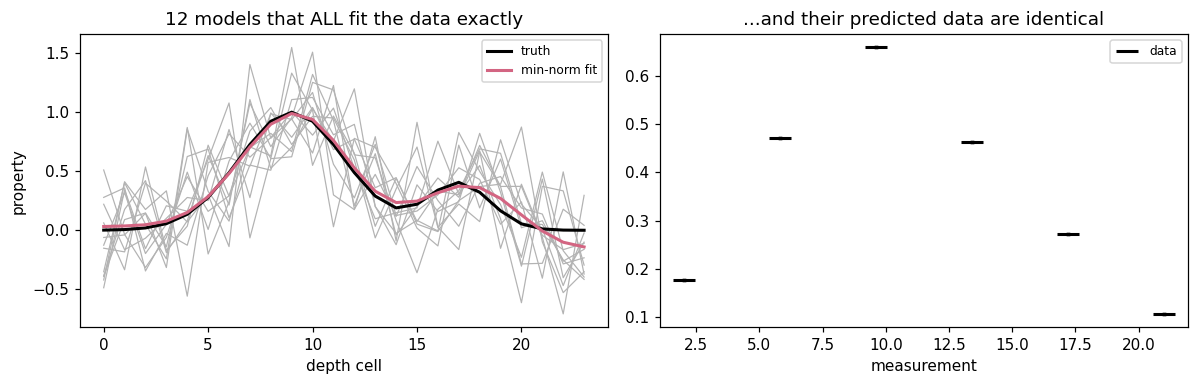

In [2]:
m_part = np.linalg.pinv(G) @ d                       # one solution (minimum-norm)
U, S, Vt = np.linalg.svd(G); null = Vt[k:]           # rows spanning the null space of G
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for _ in range(12):
    m_alt = m_part + null.T @ (rng.randn(n-k)*0.35)
    ax[0].plot(z, m_alt, color='0.7', lw=0.8)
    ax[1].plot(centers, G @ m_alt, '.', color='0.7', ms=4)
ax[0].plot(z, m_true, 'k', lw=2, label='truth'); ax[0].plot(z, m_part, '#d36582', lw=2, label='min-norm fit')
ax[0].set(title='12 models that ALL fit the data exactly', xlabel='depth cell', ylabel='property'); ax[0].legend(fontsize=8)
ax[1].plot(centers, d, 'k_', ms=14, mew=2, label='data'); ax[1].set(title='...and their predicted data are identical', xlabel='measurement'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. Regularize to choose — and quantify what you cannot

To get *one* answer we add a prior. The Bayesian linear–Gaussian form makes both the choice and its uncertainty
explicit: with data covariance $C_d=\sigma^2 I$ and a smoothness prior $C_m^{-1}=\alpha\,L^\top L$, the posterior
is Gaussian with

$$\hat{\mathbf m}=\big(G^\top C_d^{-1}G + C_m^{-1}\big)^{-1}G^\top C_d^{-1}\mathbf d,\qquad
C_{\text{post}}=\big(G^\top C_d^{-1}G + C_m^{-1}\big)^{-1}.$$

The estimate $\hat{\mathbf m}$ is the regularized image; the **diagonal of $C_{\text{post}}$ is the
per-cell uncertainty** — large exactly where the data are blind. This is the template for every inversion in the
course: an image, *and* a calibrated map of how much to trust each part of it.

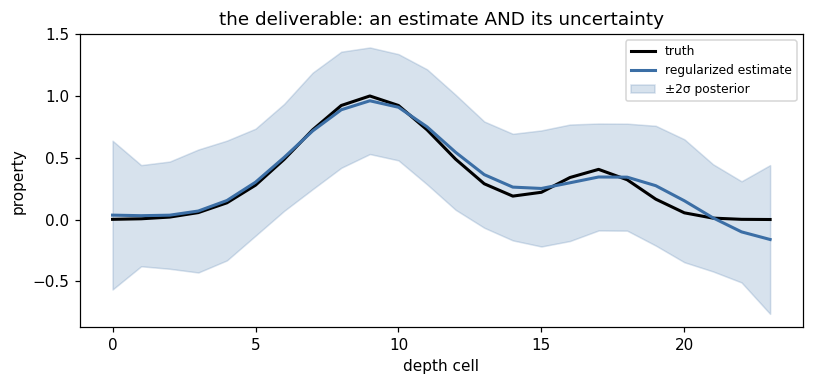

the strong body (cell 9) is resolved; the faint one (cell 17) is within the noise -- and the ±2σ band says so


In [3]:
L = np.eye(n) - np.eye(n, k=1); L[-1] = 0            # first-difference smoothness operator
alpha = 8.0
A = G.T @ G / sigma**2 + alpha * (L.T @ L)
C_post = np.linalg.inv(A); m_hat = C_post @ (G.T @ d / sigma**2)
sd = np.sqrt(np.diag(C_post))
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(z, m_true, 'k', lw=2, label='truth')
ax.plot(z, m_hat, '#3b6ea5', lw=2, label='regularized estimate')
ax.fill_between(z, m_hat-2*sd, m_hat+2*sd, color='#3b6ea5', alpha=0.2, label='±2σ posterior')
ax.set(title='the deliverable: an estimate AND its uncertainty', xlabel='depth cell', ylabel='property'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print('the strong body (cell 9) is resolved; the faint one (cell 17) is within the noise -- and the ±2σ band says so')

## 4. The decision lives in the posterior, not the point estimate

A picture is not a decision. Suppose the question is *"is there a body (property $>0.5$) near cell 17?"* — the
faint feature. The point estimate is ambiguous; the **posterior answers in probability**. Drawing from the
Gaussian posterior, we read off $P(m_{17}>0.5)$ directly — a number a decision can be built on, and the honest
form of every "is it there?" call in the course.

In [4]:
draws = rng.multivariate_normal(m_hat, C_post, size=20000)
for cell, what in [(9, 'strong body'), (17, 'faint body')]:
    p = np.mean(draws[:, cell] > 0.5)
    print('  P(property > 0.5 at cell %2d, the %-11s) = %.2f' % (cell, what, p))
print('\n-> cell 9 is a confident yes; cell 17 is a genuine maybe. The posterior, not the image, makes the call.')

  P(property > 0.5 at cell  9, the strong body) = 0.98
  P(property > 0.5 at cell 17, the faint body ) = 0.23

-> cell 9 is a confident yes; cell 17 is a genuine maybe. The posterior, not the image, makes the call.


## 5. Five habits this course practices

Every notebook earns one or more of these on real data — they are the difference between a method that *runs*
and a result you can *act on*:

1. **Non-uniqueness and resolution are the deliverable.** Quantify what the data resolve and what the prior
   filled in — a checkerboard/point-spread test, a depth–mass tradeoff, a near-pure-nugget variogram.
   → [crosshole GPR](crosshole_gpr_tomography.ipynb), [magma gravity](magma_reservoir_gravity.ipynb),
   [basin thermal](basin_thermal_history.ipynb).
2. **Accuracy ≠ calibration ≠ decision value.** The number you act on must be *calibrated*, not merely accurate;
   a more accurate model can be dangerously over-confident. → [well-log facies](well_log_facies_hmm.ipynb),
   [geochemistry](geochemical_fingerprinting.ipynb).
3. **Run the control; decline the unidentifiable.** Test whether the fancy step actually helped before crediting
   it, and refuse to report a quantity the data cannot identify. → [geochemistry](geochemical_fingerprinting.ipynb)
   (log vs log-ratio), [detrital zircon](detrital_zircon_provenance.ipynb) (the unidentifiable mixing fraction).
4. **Decisions need a calibrated probability *and* a value function.** Information has worth only where it can
   change an action. → [value of information](where_to_drill_value_of_information.ipynb),
   [well-log net pay](well_log_facies_hmm.ipynb).
5. **Real data, and honest negatives.** Every dataset here is real and openly published; when a method fails
   (a basal fossil age, an unconstrained depth), the course shows it rather than hiding it.

## 6. The toolbox

The course's rule is that **the library does the modelling** — a notebook reads *load → model → show*, so the
method is on the page, not buried in matplotlib. Two libraries provide every model:

- **[`mixle`](https://github.com/gmboquet/mixle)** — composable probability distributions and the inference
  around them: mixtures, hidden Markov models, Gaussian processes / fields, ranking models, and an inference
  stack (`mixle.inference`: bootstrap, permutation tests, multiple-testing/FDR, calibration/ECE) and a
  design-of-experiments stack (`mixle.doe`: Bayesian optimization, active learning, information gain).
- **[`mixle_pde`](https://github.com/gmboquet/mixle-pde)** — differentiable PDE/ODE forwards and the
  inverse machinery for them: eikonal traveltimes, potential-field (gravity/magnetic) sensitivities, a
  conductive geotherm and EASY%Ro maturation, and a regularized Gauss–Newton inversion engine.

When a capability is missing, we add it to the library, not the notebook (this course added
`mixle_pde.basin` for thermal history, and several `mixle`/`_geoviz` helpers).

### The map

| Module | Notebook | The earned idea |
|---|---|---|
| 1 Imaging | GPR tomography, magma gravity | resolution / non-uniqueness *is* the deliverable |
| 2 Borehole | well-log facies HMM | calibrated net pay; accuracy ≠ calibration |
| 3 Geochemistry | fingerprinting | run the control; calibrated prospectivity |
| 4 Geochronology | detrital zircon | a tested, FDR-controlled provenance call; decline the unidentifiable |
| 5 Deep time | biostratigraphy | rank uncertainty as resolution; a tested consensus margin |
| 6 Tectonics | basin thermal history | honest UQ from nuggety data; geothermal + oil decisions |
| 7 Decision | value of information | spend the next dollar where it changes the decision |

Read them in any order; each is self-contained, on real data, and ends in a decision with its uncertainty
stated. If you read only one first, read **basin thermal history** — it is the course's lesson (a confident map
with a dishonest uncertainty, fixed) in miniature.